# Audification of Kepler Lightcurves
Hands on Astronomical Data Sonification, Adrián García Riber, SVO 2026

https://archive.stsci.edu/missions-and-data/kepler

This work includes data collected by the Kepler mission and obtained from the MAST data archive at the Space Telescope Science Institute (STScI). Funding for the Kepler mission is provided by the NASA Science Mission Directorate. STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA contract NAS 5–26555.

In [1]:
from astropy.timeseries import TimeSeries
import matplotlib.pylab as plt
import numpy as np
import sounddevice as sd

In [2]:
file = 'KeplerLightcurves/kplr011853905-2009166043257_llc.fits'

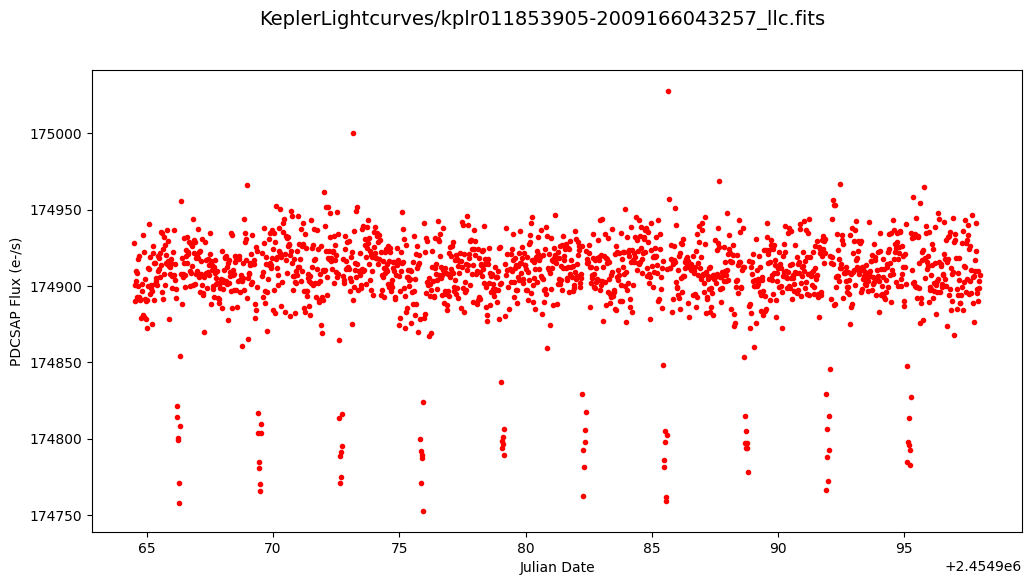

LC dimension:  1639


In [3]:
lightcurve = TimeSeries.read(file, format='kepler.fits', unit_parse_strict='silent') 

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
time = lightcurve.time.jd
flux = lightcurve['pdcsap_flux']
ax.plot(time, flux, 'r.')
ax.set_xlabel('Julian Date')
ax.set_ylabel('PDCSAP Flux (e-/s)')
plt.show()
print("LC dimension: ", len(lightcurve['pdcsap_flux']))

Kepler 4 star (KIC 11853905), RA(2000): 285.6156 DEC(2000): 50.1358, available at the Mikulsky Archive for Space Telescope (MAST).  The curve shows planetary transits with relative depth of 0.87.10−3, orbital period of 3.213 days, and duration of about 3.95 hours around the sunlike star.

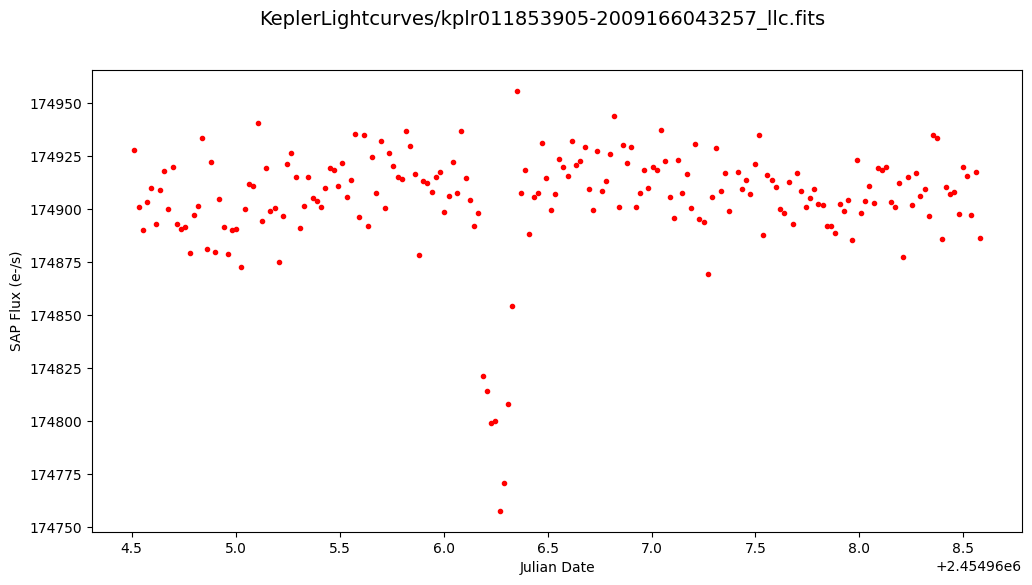

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
time = lightcurve.time.jd
flux = lightcurve['pdcsap_flux']
ax.plot(time[:200], flux[:200] , 'r.')
ax.set_xlabel('Julian Date')
ax.set_ylabel('SAP Flux (e-/s)')
plt.show()

## Amplitude normalization

In [5]:
flux = lightcurve['pdcsap_flux']

In [6]:
scaled_flux = 1/348000*flux

In [7]:
sd.play(scaled_flux , 44100)

In [8]:
sd.stop()

In [9]:
scaled_flux.value

array([0.5026665 , 0.5025888 , 0.5025579 , ..., 0.50258297, 0.50259596,
       0.50260735], shape=(1639,), dtype=float32)

In [10]:
scaled_flux.shape

(1639,)

## Cleaning 'nans'

In [11]:
mask = ~np.isnan(scaled_flux)
clean_flux = scaled_flux[mask]
clean_times = np.arange(len(clean_flux))  # Or your BJD normalized

## Interpolation

In [12]:
import numpy as np
from scipy.signal import resample
from scipy.interpolate import interp1d

# Fourier resample (preserves power, good for periodic signals)
augmented_flux = resample(clean_flux, 500000)
augmented_times = np.arange(len(augmented_flux)) 
print(augmented_flux.shape) 

(500000,)


In [13]:
augmented_flux

array([0.50266635, 0.50266635, 0.5026663 , ..., 0.50266653, 0.5026664 ,
       0.5026664 ], shape=(500000,), dtype=float32)

In [14]:
sd.play(augmented_flux , 44100)

In [15]:
sd.stop()

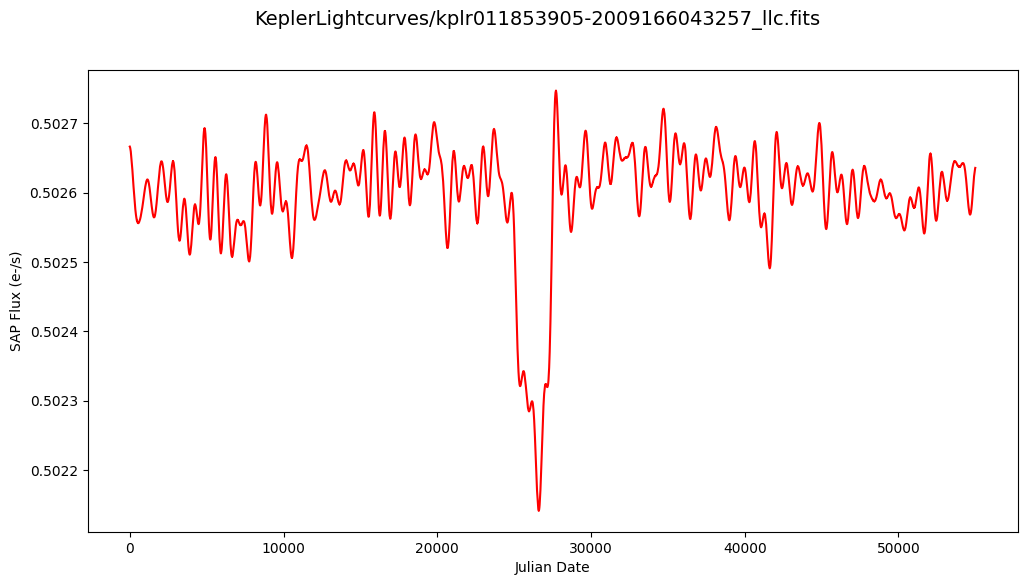

LC dimension:  1639


In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
ax.plot(augmented_times[:55000], augmented_flux[:55000] , 'r')
ax.set_xlabel('Julian Date')
ax.set_ylabel('SAP Flux (e-/s)')
plt.show()
print("LC dimension: ", len(lightcurve['pdcsap_flux']))

In [17]:
fs = 44100
duration = 100

In [18]:
test = np.linspace(0, duration, int(fs*duration), endpoint=False)
test_times = np.arange(len(test))

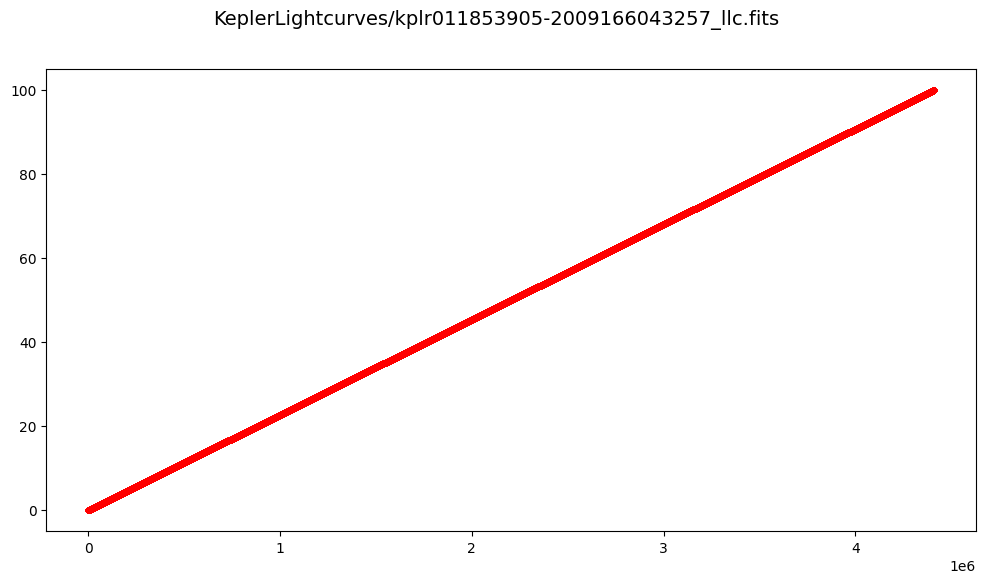

LC dimension:  4410000


In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
ax.plot(test_times, test , 'r.')
plt.show()
print("LC dimension: ", len(test))

In [20]:
sd.play(test , 44100)

In [21]:
sd.stop()